## **SIN 393 – Introduction to Computer Vision (2026)**

### Prof. João Fernando Mari ([*joaofmari.github.io*](https://joaofmari.github.io/))

Copyright (c) 2026 João Fernando Mari.  
Licensed under the MIT License.

---

# Lecture 1 - Notebook 1b - From images to features
## Flowers Dataset
---

## Importing the Required Libraries
---

In [4]:
import os

import numpy as np
from skimage import io, transform, exposure

import matplotlib.pyplot as plt
import pandas as pd

## The dataset 
---
**Flowers Recognition Dataset**
* A set of flower images
* 4,317 images
* 5 classes

* **Versions of the Flavia set:**
    * Full dataset (all images of 5 classes)
        * ```data/flowers```
    * All images of 3 selected classes
        * ```data/flowers_toy```
    * Only 6 images of 3 selected classes
        * ```data/flowers_toy2```

In [5]:
# 3 classes - 50 images per classes
ds_path = 'data/flowers_toy'

# 3 classes - 6 images per class
#### ds_path = '../data/flowers_toy2'

## Loading the images from the dataset
---

The dataset is organized into folders, with one folder for each class:

    dataset/
    ├── class_1/
    │   ├── image_1.jpg
    │   ├── image_2.jpg
    │   └── ...
    ├── class_2/
    │   ├── image_1.jpg
    │   ├── image_2.jpg
    │   └── ...
    └── ...

The images are loaded from the class folders and resized to 64 x 64 pixels. 

The corresponding class labels and filenames are also stored for later use.

In [6]:
# List of dataset classes
class_names = sorted(os.listdir(ds_path))

# Lists to store images, labels, and filenames
images = []
labels = []
filenames = []

# Iterate through the dataset classes
for class_name in class_names:

    # List all images in the current class folder
    class_path = os.path.join(ds_path, class_name)
    image_names = sorted(os.listdir(class_path))

    # Iterate through the images
    for image_name in image_names:
        # Load the image
        image = io.imread(os.path.join(class_path, image_name))

        # Resize the image to 64 x 64 pixels
        image = transform.resize(image, (64, 64), anti_aliasing=True)

        # Store the image, label, and filename
        images.append(image)
        labels.append(class_name)
        filenames.append(image_name)

# Convert lists to NumPy arrays
labels = np.array(labels)

# Display the dataset information
print(f"Number of images: {len(images)}")
print(f"Number of labels: {labels.shape[0]}")
print(f"Filenames: {len(filenames)}")
print(f"Classes: {class_names}")
print()

Number of images: 150
Number of labels: 150
Filenames: 150
Classes: ['daisy', 'rose', 'sunflower']



### Visualizing Dataset Images

Display the first `N` images from each class to visually inspect the dataset and its class variability.

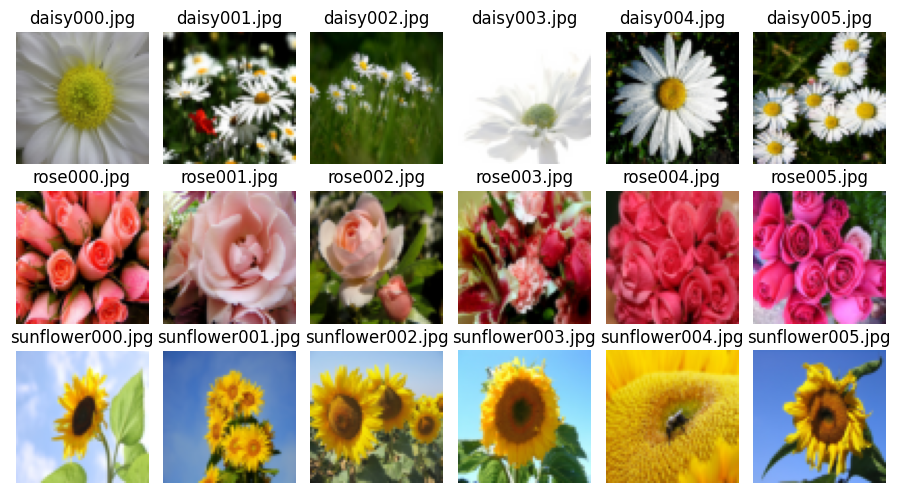

In [7]:
# Number of images to show per class
n_images = 6

# Select the first N images from each class
image_list_temp = []
filename_list_temp = []

for class_name in class_names:
    # Indices of images belonging to the current class
    indices = np.where(labels == class_name)[0][:n_images]

    for idx in indices:
        image_list_temp.append(images[idx])
        filename_list_temp.append(filenames[idx])

# Display the selected images
fig, ax = plt.subplots(len(class_names), n_images, figsize=(9, 5))

for i, (image, filename) in enumerate(zip(image_list_temp, filename_list_temp)):
    row = i // n_images
    col = i % n_images

    ax[row, col].imshow(image)
    ax[row, col].set_title(filename)
    ax[row, col].axis('off')

fig.tight_layout()
plt.show()

## Extracting Color Histogram Features
---

* Color histograms describe the distribution of pixel intensities in an image.
* We compute a 32-bin histogram for each RGB channel and concatenate them into a single feature vector.
* Each image is represented by **96 features (32 × 3 channels)**.

In [8]:
# 2D array with the image features
# Each row stores information about an image. Each column stores one feature.
feature_mat = []

# Number of histogram bins
n_bins = 32

for i, (image, label) in enumerate(zip(images, labels)):
    
    # Convert the image data type to float
    # img_float = util.img_as_float(image)
    img_float = image

    # Compute the histogram for each channel
    hist_r = exposure.histogram(img_float[:,:,0], nbins=n_bins)[0]
    hist_g = exposure.histogram(img_float[:,:,1], nbins=n_bins)[0]
    hist_b = exposure.histogram(img_float[:,:,2], nbins=n_bins)[0]

    # Concatenate the histograms into a single feature vector
    feature_list = np.concatenate((hist_r, hist_g, hist_b))

    # Add the feature vector to the feature matrix
    feature_mat.append(feature_list)

# Convert the feature matrix to a NumPy array
feature_mat = np.array(feature_mat)

print("Feature matrix shape:", feature_mat.shape)

Feature matrix shape: (150, 96)


## Visualizing the Extracted Features

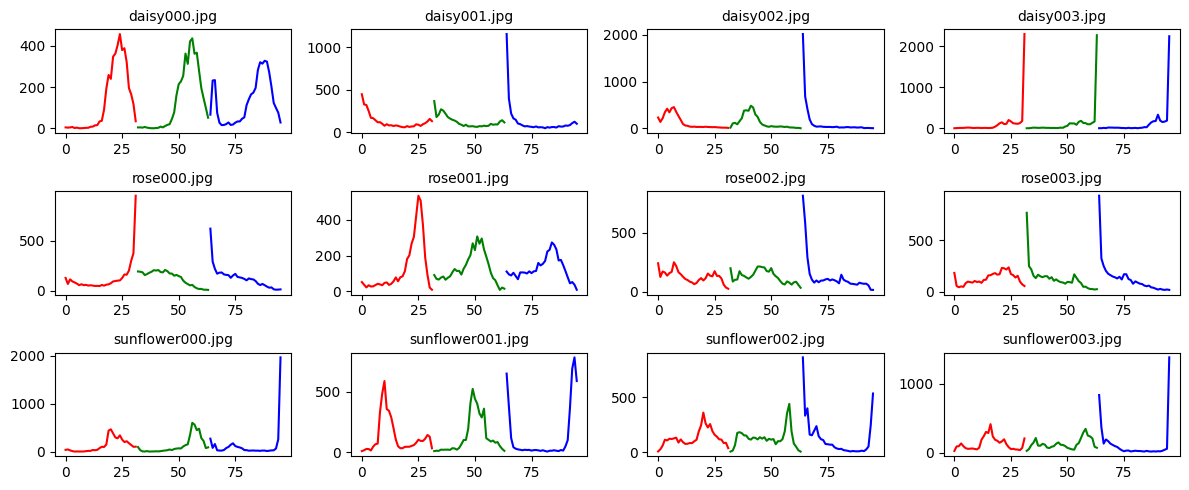

In [9]:
# Select the first 4 samples from each class
feature_mat_temp = []
filename_list_temp = []

for class_name in class_names:
    idx = np.where(labels == class_name)[0][:4]

    feature_mat_temp += [feature_mat[i] for i in idx]
    filename_list_temp += [filenames[i] for i in idx]


# Plot the RGB histograms
fig, ax = plt.subplots(3, 4, figsize=(12, 5))

for i, (feature, filename) in enumerate(
    zip(feature_mat_temp, filename_list_temp)
):
    row, col = divmod(i, 4)

    ax[row, col].plot(range(0, 32), feature[0:32], color='r')
    ax[row, col].plot(range(32, 64), feature[32:64], color='g')
    ax[row, col].plot(range(64, 96), feature[64:96], color='b')

    ax[row, col].set_title(filename, fontsize=10)

fig.tight_layout()
plt.show()

## Creating and Saving the Feature Dataset

The extracted features are organized into a tabular dataset, with one row per image and the corresponding filename and class label. The dataset is then saved to a CSV file for use in the classification notebooks.

In [10]:
# Create feature names
feature_names = (
    [f"R_{i}" for i in range(n_bins)] +
    [f"G_{i}" for i in range(n_bins)] +
    [f"B_{i}" for i in range(n_bins)]
)

# Create a DataFrame with the extracted features
features_df = pd.DataFrame(feature_mat, columns=feature_names)

# Add image filenames and class labels
features_df.insert(0, "filename", filenames)
features_df.insert(1, "label", labels)

# Display the first rows of the dataset
features_df.head()

,filename,label,R_0,R_1,R_2,R_3,R_4,R_5,R_6,R_7,...,B_22,B_23,B_24,B_25,B_26,B_27,B_28,B_29,B_30,B_31
0,daisy000.jpg,daisy,4,3,4,6,1,3,0,0,...,321,314,328,324,272,202,123,99,76,28
1,daisy001.jpg,daisy,447,328,321,252,171,167,143,119,...,57,73,68,69,81,78,86,109,125,102
2,daisy002.jpg,daisy,233,139,216,345,421,344,434,455,...,23,24,18,21,24,8,9,10,7,5
3,daisy003.jpg,daisy,2,5,9,10,10,15,18,16,...,88,143,172,178,331,187,153,164,188,2241
4,daisy004.jpg,daisy,1033,292,235,147,107,82,62,66,...,93,88,100,118,111,125,157,172,182,85


In [11]:
# Save the feature dataset
features_df.to_csv("flowers_features.csv", index=False)

## License
---
Copyright (c) 2026 João Fernando Mari.

The Python source code and Jupyter Notebook are licensed under the MIT License.  
See the `LICENSE` file in the repository for details.

Third-party materials remain subject to the rights and licenses of their respective authors and owners.

## Bibliography
---
* GONZALEZ, R.C.; WOODS, R.E.; Digital Image Processing. 3rd Edition. Prentice Hall, 2008.
* DUDA, R.O.; HART, P.E.; STORK, D.G. Pattern Classification. 2nd Edition. Wiley-Interscience, 2001.
* COSTA, L. DA F.; CESAR-JR., R. M. Shape analysis and classification: theory and practice. CRC Press, 2000. Chapter 8.
* Scikit-image documentation.
    - https://scikit-image.org/docs/stable/

Flowers Recognition:
* https://www.kaggle.com/datasets/alxmamaev/flowers-recognition 